In [1]:
import pandas as pd
import numpy as np
import shap
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score

In [2]:
#load the data
X_train = pd.read_csv('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/data/X_train_processed.csv')
y = pd.read_csv('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/data/y_train.csv').squeeze() 



In [3]:
#LightGBM and XGBoost best params
best_lgb_params = {
    'n_estimators': 690,
    'learning_rate': 0.02011820620908632,
    'max_depth': 6,
    'num_leaves': 57,
    'min_child_samples': 39,
    'subsample': 0.506821746158421,
    'colsample_bytree': 0.5051642633258705,
    'reg_alpha': 0.0005712165849266721,
    'reg_lambda': 0.002714338283287307,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

best_xgb_params = {
    'n_estimators': 953,
    'learning_rate': 0.017121448472152242,
    'max_depth': 4,
    'min_child_weight': 2,
    'subsample': 0.500292621295294,
    'colsample_bytree': 0.526591163035804,
    'reg_alpha': 0.003351561224939414,
    'reg_lambda': 0.0002343004339290042,
    'random_state': 42,
    'n_jobs': -1
}

In [4]:
# Train XGBoost on full data — best model for SHAP
xgb_model = xgb.XGBRegressor(**best_xgb_params)
xgb_model.fit(X_train, y)

# Train LightGBM
lgb_model = lgb.LGBMRegressor(**best_lgb_params)
lgb_model.fit(X_train, y)


,boosting_type,'gbdt'
,num_leaves,57
,max_depth,6
,learning_rate,0.02011820620908632
,n_estimators,690
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,39


In [5]:
# Create SHAP explainer
# TreeExplainer is optimized for tree-based models
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for training data
# This tells us how each feature contributed to each prediction
print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_train)

print(f"SHAP values shape: {shap_values.shape}")
# Same shape as X_train — one SHAP value per feature per sample

Calculating SHAP values...
SHAP values shape: (1456, 238)


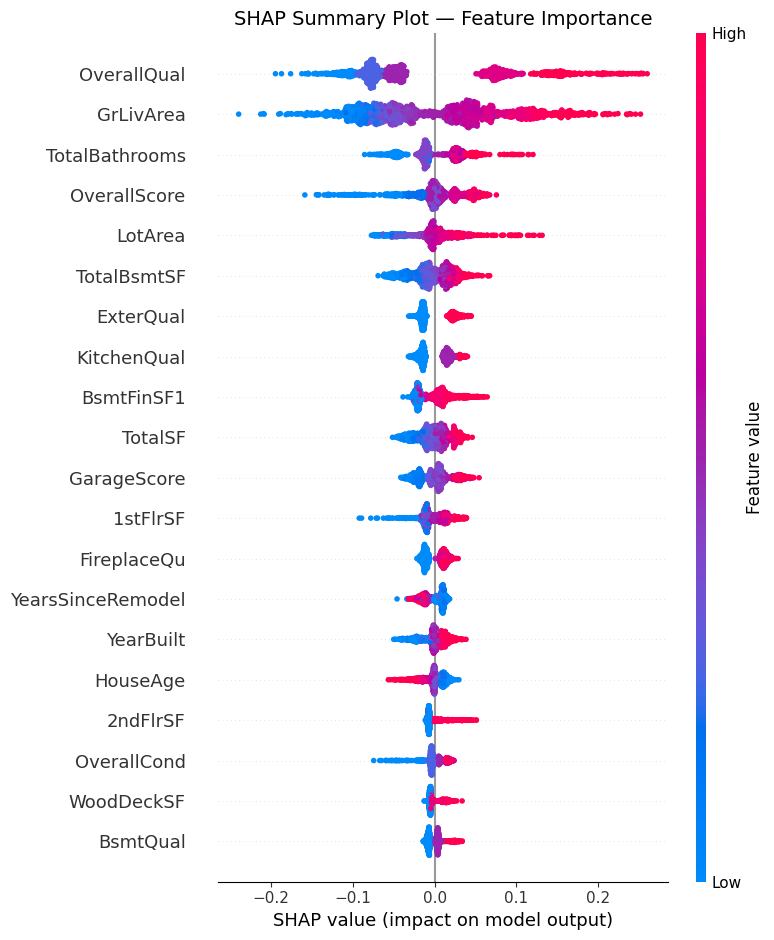

Summary plot saved


In [6]:
# Summary Plot
# Most important visualization — shows global feature importance
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values,
    X_train,
    max_display=20,
    show=False
)
plt.title('SHAP Summary Plot — Feature Importance', fontsize=14)
plt.tight_layout()
plt.savefig('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/results/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary plot saved")

 95%|=================== | 1377/1456 [00:17<00:00]       

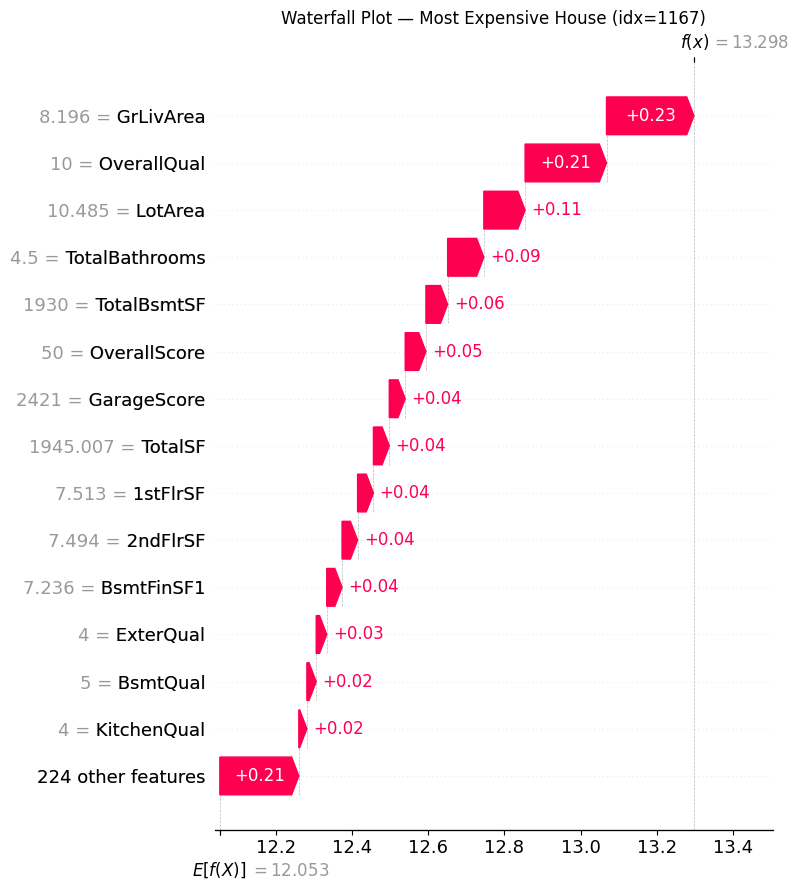

Actual price:    $625,000
Predicted price: $595,767
Error:           $29,233


In [8]:
#Waterfall Plot (Single Prediction)

X_train_float = X_train.astype(float)

# Waterfall Plot
most_expensive_idx = y.argmax()

explainer_v2 = shap.Explainer(xgb_model, X_train_float)
shap_explanation = explainer_v2(X_train_float)

plt.figure(figsize=(12, 8))
shap.plots.waterfall(
    shap_explanation[most_expensive_idx],
    max_display=15,
    show=False
)
plt.title(f'Waterfall Plot — Most Expensive House (idx={most_expensive_idx})')
plt.tight_layout()
plt.savefig('../results/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

actual_price = np.expm1(y.iloc[most_expensive_idx])
predicted_price = np.expm1(xgb_model.predict(X_train_float.iloc[[most_expensive_idx]])[0])
print(f"Actual price:    ${actual_price:,.0f}")
print(f"Predicted price: ${predicted_price:,.0f}")
print(f"Error:           ${abs(actual_price-predicted_price):,.0f}")

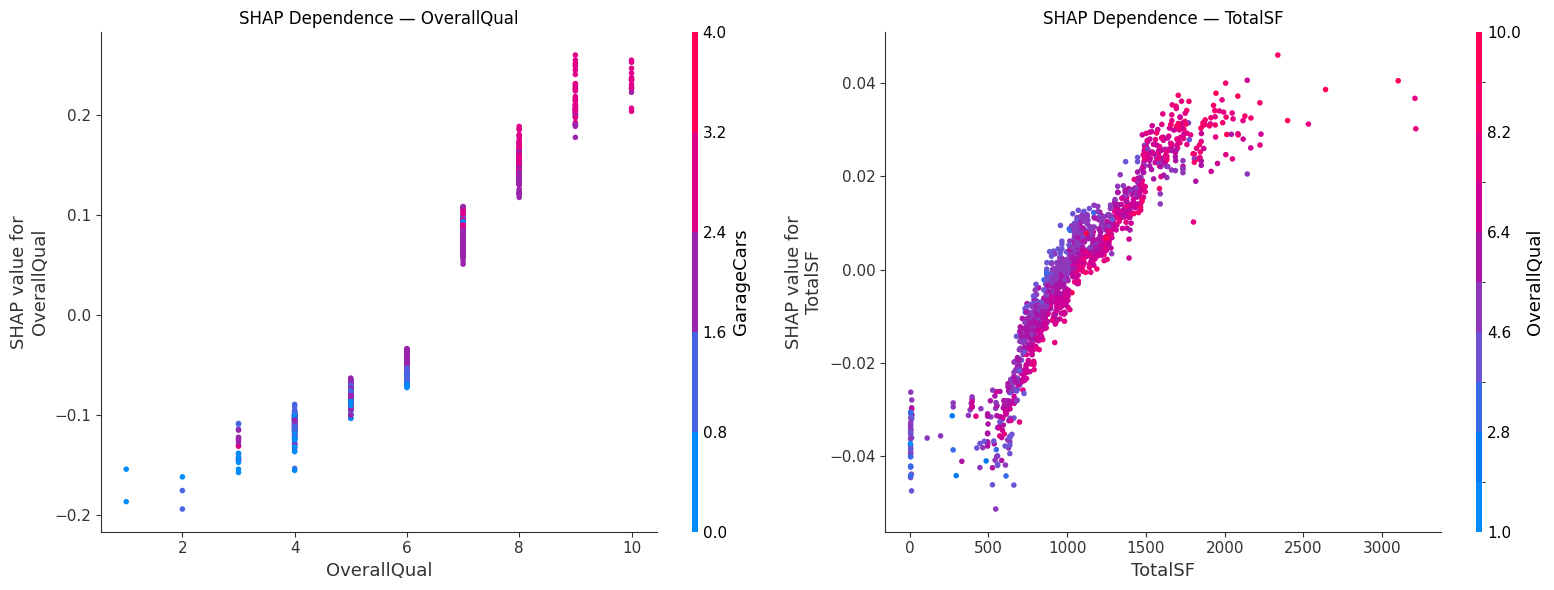

In [9]:
#Dependence Plots
# How does OverallQual affect predictions?
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# OverallQual dependence
shap.dependence_plot(
    'OverallQual',
    shap_values,
    X_train,
    ax=axes[0],
    show=False
)

axes[0].set_title('SHAP Dependence — OverallQual')

# TotalSF dependence
shap.dependence_plot(
    'TotalSF',
    shap_values,
    X_train,
    ax=axes[1],
    show=False
)
axes[1].set_title('SHAP Dependence — TotalSF')

plt.tight_layout()
plt.savefig('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/results/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
#MLflow Experiment Tracking
# Set up MLflow
mlflow.set_experiment("House_Price_Prediction")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def rmse_cv(model, X, y):
    scores = -cross_val_score(
        model, X, y,
        scoring='neg_root_mean_squared_error',
        cv=kf
    )
    return scores.mean(), scores.std()

# Log all models as MLflow runs
models_to_log = {
    'Ridge_baseline': Pipeline([
        ('scaler', RobustScaler()),
        ('model', Ridge(alpha=10))
    ]),
    'XGBoost_tuned': xgb.XGBRegressor(**best_xgb_params),
    'LightGBM_tuned': lgb.LGBMRegressor(**best_lgb_params),
}

for model_name, model in models_to_log.items():
    with mlflow.start_run(run_name=model_name):
        # Calculate metrics
        rmse_mean, rmse_std = rmse_cv(model, X_train, y)
        
        # Log parameters
        if hasattr(model, 'get_params'):
            mlflow.log_params(model.get_params())
        
        # Log metrics
        mlflow.log_metric('rmse_mean', rmse_mean)
        mlflow.log_metric('rmse_std', rmse_std)
        
        # Train and log model
        model.fit(X_train, y)
        
        print(f" {model_name}: RMSE={rmse_mean:.4f} ± {rmse_std:.4f}")

print("\nAll runs logged to MLflow")

2026/04/19 05:35:10 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/19 05:35:10 INFO mlflow.store.db.utils: Updating database tables
2026/04/19 05:35:12 INFO mlflow.tracking.fluent: Experiment with name 'House_Price_Prediction' does not exist. Creating a new experiment.


 Ridge_baseline: RMSE=0.1119 ± 0.0081
 XGBoost_tuned: RMSE=0.1140 ± 0.0111
 LightGBM_tuned: RMSE=0.1192 ± 0.0143

All runs logged to MLflow


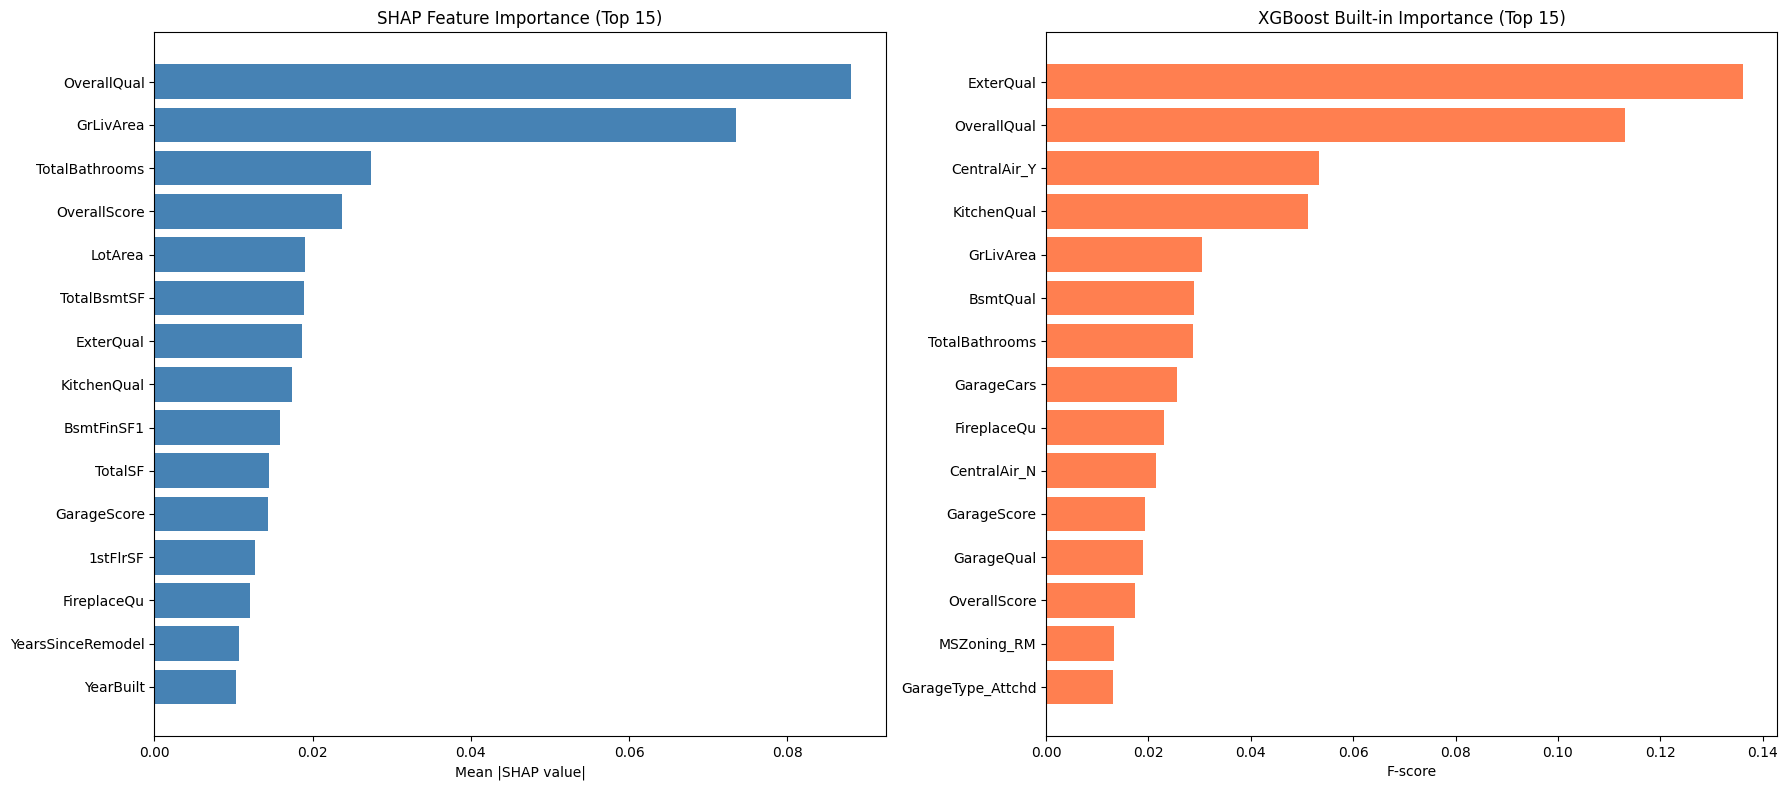

In [11]:
# Compare SHAP importance vs built-in importance
shap_importance = pd.DataFrame({
    'feature': X_train.columns,
    'shap_importance': np.abs(shap_values).mean(axis=0)
}).sort_values('shap_importance', ascending=False).head(15)

xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'xgb_importance': xgb_model.feature_importances_
}).sort_values('xgb_importance', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# SHAP importance
axes[0].barh(shap_importance['feature'][::-1],
             shap_importance['shap_importance'][::-1],
             color='steelblue')
axes[0].set_title('SHAP Feature Importance (Top 15)')
axes[0].set_xlabel('Mean |SHAP value|')

# XGBoost built-in importance
axes[1].barh(xgb_importance['feature'][::-1],
             xgb_importance['xgb_importance'][::-1],
             color='coral')
axes[1].set_title('XGBoost Built-in Importance (Top 15)')
axes[1].set_xlabel('F-score')

plt.tight_layout()
plt.savefig('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/results/feature_importance_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()